# Part 3: NLP and Sequence Modeling Mini Project

## Objective
The objective of this project is to build a basic NLP pipeline and compare traditional text vectorization techniques with sequence-based deep learning methods.

This project includes:
- Text preprocessing
- TF-IDF vectorization
- Baseline NLP model
- LSTM sequence model
- Attention and transformer reflection

In [74]:
# Install required libraries
!pip install nltk scikit-learn tensorflow -q

In [75]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
# Extract dataset zip

with zipfile.ZipFile('/content/part_3_nlp_sequence_modeling.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted")

Dataset Extracted


In [77]:
# Load correct NLP dataset

csv_file = "/content/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"

df = pd.read_csv(csv_file)

print(df.head())

print(df.columns)

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [78]:
# Load dataset

df = pd.read_csv(csv_file)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [79]:
df.columns

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

In [80]:
# Select required columns

df = df[['customer_message', 'sentiment_label']]

# Rename columns

df.columns = ['text', 'label']

# Display dataset

df.head()

,text,label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


# Task 1: Dataset Understanding

In this section:
- Number of records
- Target labels
- Sample text
- Average text length
- Class distribution

are analyzed.

In [81]:
print("Number of Records:", len(df))

print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nSample Text:")
print(df['text'].head())

# Average text length
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("\nAverage Text Length:", df['text_length'].mean())

Number of Records: 1500

Class Distribution:
label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Text:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: text, dtype: object

Average Text Length: 12.722666666666667


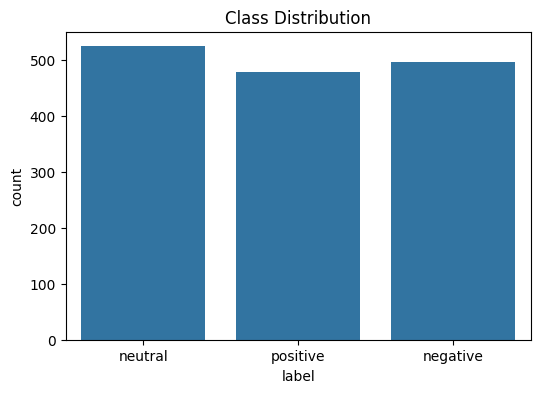

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['label'])

plt.title("Class Distribution")

plt.savefig("class_distribution.png", bbox_inches='tight')

plt.show()

In [83]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Task 2: Text Preprocessing

Text preprocessing includes:
- Lowercasing
- Removing special characters
- Tokenization
- Stopword removal

In [84]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['clean_text'] = df['text'].astype(str).apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


# Task 3: Text Vectorization

Text data cannot be directly understood by machine learning models.

Therefore, text is converted into numerical vectors using TF-IDF vectorization.

TF-IDF helps identify important words in documents.

In [85]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()

encoder = LabelEncoder()

y = encoder.fit_transform(df['label'])

print("Vectorization Completed")
print("Shape:", X.shape)

Vectorization Completed
Shape: (1500, 146)


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Test Split Completed")

Train Test Split Completed


# Task 4: Baseline Model

A Logistic Regression model is used as the baseline NLP classifier.

In [87]:
model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



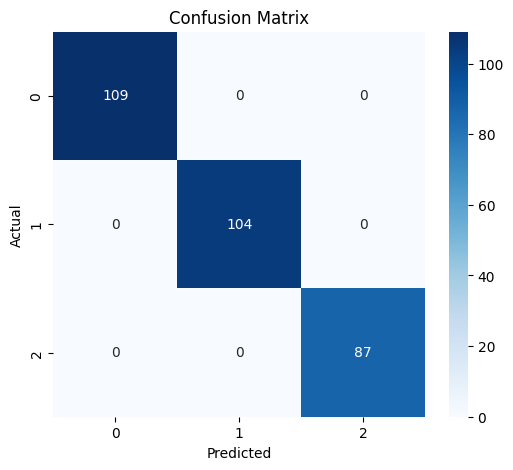

In [88]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", bbox_inches='tight')

plt.show()

# Task 5: Sequence Model Using LSTM

LSTM is used for sequence modeling in NLP tasks.

Architecture:
- Input sequence
- Embedding layer
- LSTM layer
- Dense output layer

In [89]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

padded_sequences = pad_sequences(
    sequences,
    maxlen=100
)

print("Padding Completed")

Padding Completed


In [90]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(len(np.unique(y)), activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [92]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.6833 - loss: 0.9379 - val_accuracy: 0.8700 - val_loss: 0.6423
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.9017 - loss: 0.4346 - val_accuracy: 1.0000 - val_loss: 0.1791
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 1.0000 - loss: 0.0867 - val_accuracy: 1.0000 - val_loss: 0.0333
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.9992 - loss: 0.0352 - val_accuracy: 1.0000 - val_loss: 0.0163
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 0.0066


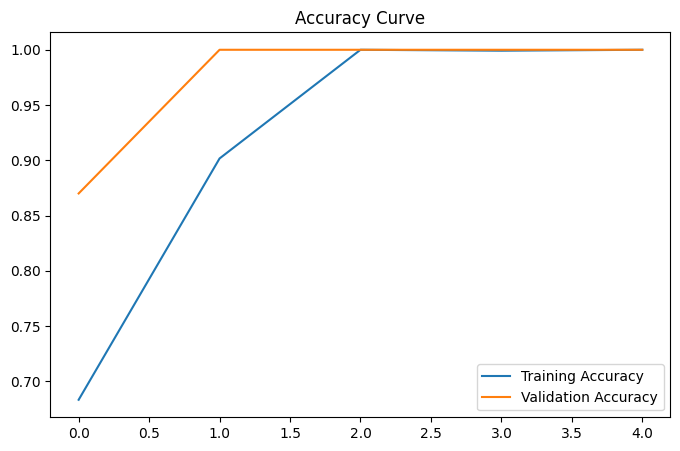

In [93]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.title("Accuracy Curve")

plt.savefig("model_evaluation.png", bbox_inches='tight')

plt.show()

In [94]:
sample_predictions = lstm_model.predict(X_test_seq[:5])

predicted_classes = np.argmax(sample_predictions, axis=1)

print("Predictions:")

for i in range(5):

    print("Predicted:",
          encoder.inverse_transform([predicted_classes[i]])[0])

    print("Actual:",
          encoder.inverse_transform([y_test_seq[i]])[0])

    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Predictions:
Predicted: neutral
Actual: neutral

Predicted: positive
Actual: positive

Predicted: neutral
Actual: neutral

Predicted: negative
Actual: negative

Predicted: negative
Actual: negative



In [95]:
with open("sample_predictions.txt", "w") as f:

    for i in range(5):

        f.write(
            f"Predicted: {encoder.inverse_transform([predicted_classes[i]])[0]}\n"
        )

        f.write(
            f"Actual: {encoder.inverse_transform([y_test_seq[i]])[0]}\n\n"
        )

print("Sample Predictions Saved")

Sample Predictions Saved


# Task 6: Attention and Transformer Reflection

## Why RNNs struggle with long-term dependencies
Traditional RNNs struggle to remember information from earlier time steps due to vanishing gradients.

## How LSTMs help with memory
LSTMs use memory cells and gating mechanisms to preserve important information over longer sequences.

## What attention solves
Attention mechanisms allow models to focus on important parts of the input sequence instead of compressing everything into one vector.

## Why transformers are important
Transformers process sequences in parallel and use self-attention mechanisms, making them highly effective for NLP and Generative AI applications such as ChatGPT and modern language models.

In [96]:
os.makedirs("results", exist_ok=True)

In [97]:
import shutil

shutil.move("model_evaluation.png", "results/model_evaluation.png")

shutil.move("sample_predictions.txt", "results/sample_predictions.txt")

shutil.move("confusion_matrix.png", "results/confusion_matrix.png")

print("Files Moved Successfully")

Files Moved Successfully
